In [3]:
# Cell 1: Import libraries and load clean data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Make charts appear inside the notebook
%matplotlib inline

# Load clean data
df = pd.read_csv('data/clean_reviews.csv')
df['review_date'] = pd.to_datetime(df['review_date'])

# Set a nice style for all charts
plt.style.use('seaborn-v0_8-whitegrid')

print("✓ Ready to make charts!")
print("Shape:", df.shape)

✓ Ready to make charts!
Shape: (1111, 11)


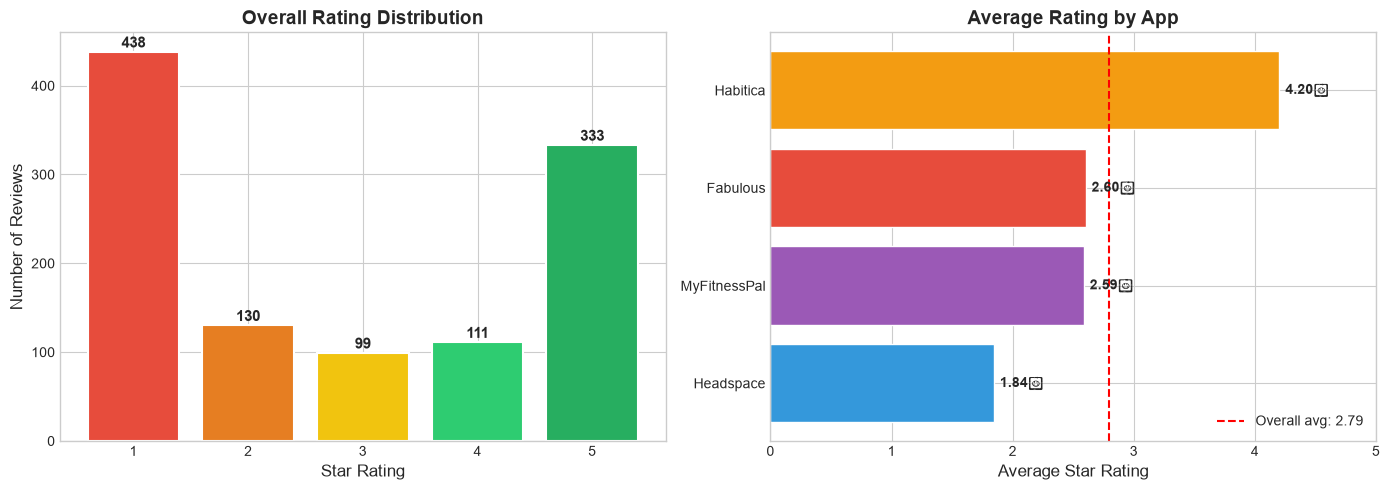

✓ Chart 1 saved!


In [4]:
# Cell 2: Chart 1 - Rating Distribution
# Question: "How are ratings spread across our dataset?"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left chart: Overall rating counts ---
rating_counts = df['rating'].value_counts().sort_index()

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

bars = axes[0].bar(
    rating_counts.index,
    rating_counts.values,
    color=colors,
    edgecolor='white',
    linewidth=1.5
)

axes[0].set_title('Overall Rating Distribution', 
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Star Rating', fontsize=12)
axes[0].set_ylabel('Number of Reviews', fontsize=12)

# Add count labels on top of each bar
for bar, count in zip(bars, rating_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        str(count),
        ha='center',
        fontweight='bold',
        fontsize=11
    )

# --- Right chart: Average rating per app ---
avg_by_app = df.groupby('app_name')['rating'].mean().sort_values()

app_colors = ['#3498db', '#9b59b6', '#e74c3c', '#f39c12']

axes[1].barh(
    avg_by_app.index,
    avg_by_app.values,
    color=app_colors,
    edgecolor='white'
)

axes[1].set_title('Average Rating by App', 
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Star Rating', fontsize=12)
axes[1].set_xlim(0, 5)

# Add a vertical line showing overall average
overall_avg = df['rating'].mean()
axes[1].axvline(
    x=overall_avg,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Overall avg: {overall_avg:.2f}'
)
axes[1].legend()

# Add value labels
for app, avg in avg_by_app.items():
    axes[1].text(
        avg + 0.05, 
        list(avg_by_app.index).index(app),
        f'{avg:.2f}★',
        va='center',
        fontweight='bold'
    )

plt.tight_layout()

# Save the chart
import os
os.makedirs('outputs/charts', exist_ok=True)
plt.savefig('outputs/charts/01_rating_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart 1 saved!")

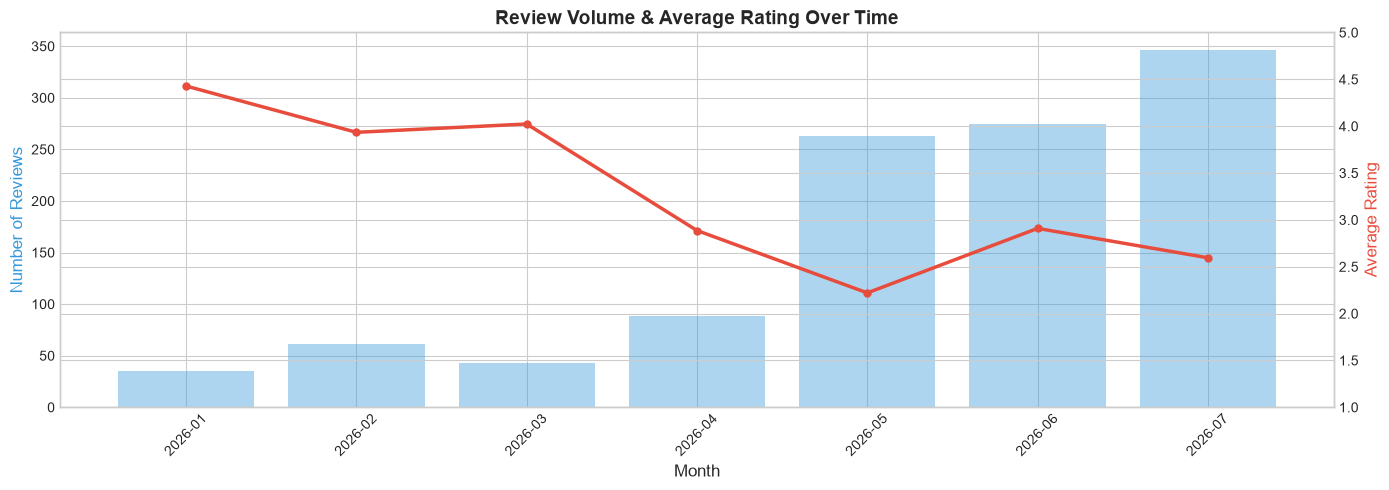

✓ Chart 2 saved!


In [5]:
# Cell 3: Chart 2 - Review Volume Over Time
# Question: "When are users most actively leaving reviews?"

# Group by year and month
df['year_month'] = df['review_date'].dt.to_period('M')
monthly = df.groupby('year_month').agg(
    review_count=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()
monthly['year_month'] = monthly['year_month'].astype(str)

# Only keep months with at least 5 reviews
monthly = monthly[monthly['review_count'] >= 5]

fig, ax1 = plt.subplots(figsize=(14, 5))

# Bar chart for review count
ax1.bar(
    monthly['year_month'],
    monthly['review_count'],
    color='#3498db',
    alpha=0.4,
    label='Review Count'
)
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Number of Reviews', fontsize=12, color='#3498db')
ax1.tick_params(axis='x', rotation=45)

# Line chart for average rating (second y-axis)
ax2 = ax1.twinx()
ax2.plot(
    monthly['year_month'],
    monthly['avg_rating'],
    color='#e74c3c',
    linewidth=2.5,
    marker='o',
    markersize=5,
    label='Avg Rating'
)
ax2.set_ylabel('Average Rating', fontsize=12, color='#e74c3c')
ax2.set_ylim(1, 5)

plt.title('Review Volume & Average Rating Over Time', 
          fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/charts/02_reviews_over_time.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart 2 saved!")

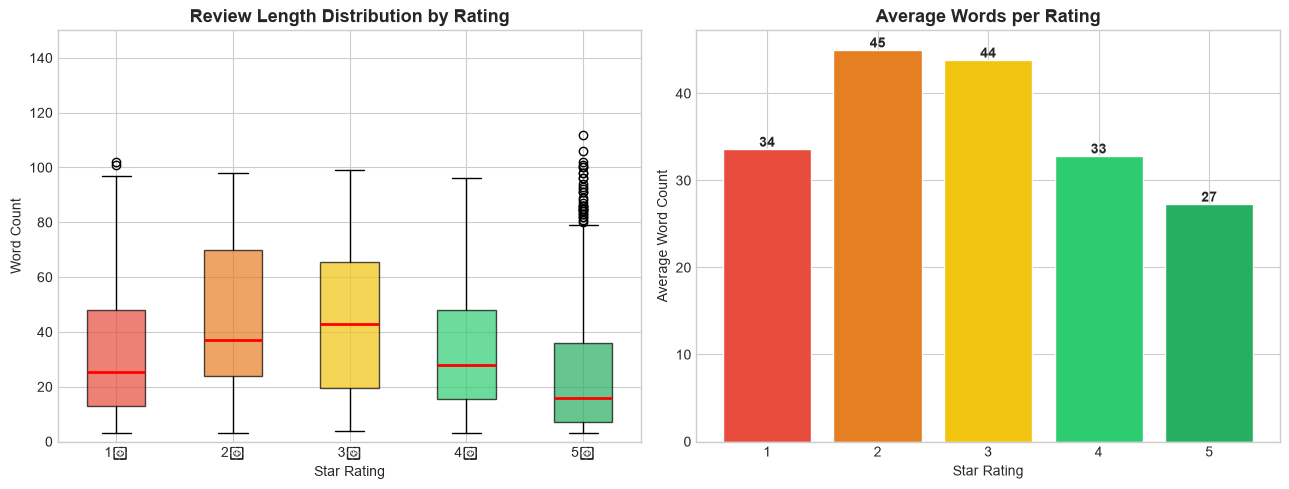

✓ Chart 3 saved!

Average words per rating:
  1 star: 34 words
  2 star: 45 words
  3 star: 44 words
  4 star: 33 words
  5 star: 27 words


In [9]:
# Cell 4: Chart 3 - Do unhappy users write longer reviews?

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: Box plot ---
data_by_rating = [
    df[df['rating'] == r]['review_word_count'].values
    for r in [1, 2, 3, 4, 5]
]

bp = axes[0].boxplot(
    data_by_rating,
    tick_labels=['1★', '2★', '3★', '4★', '5★'],  # ← changed 'labels' to 'tick_labels'
    patch_artist=True,
    medianprops=dict(color='red', linewidth=2)
)

box_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_title('Review Length Distribution by Rating', 
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Word Count')
axes[0].set_ylim(0, 150)

# --- Right: Average word count per rating ---
avg_words = df.groupby('rating')['review_word_count'].mean()

axes[1].bar(
    avg_words.index,
    avg_words.values,
    color=box_colors,
    edgecolor='white'
)
axes[1].set_title('Average Words per Rating', 
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Average Word Count')

for rating, avg in avg_words.items():
    axes[1].text(
        rating, avg + 0.3,
        f'{avg:.0f}',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig('outputs/charts/03_wordcount_vs_rating.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart 3 saved!")

# Print the actual numbers
print("\nAverage words per rating:")
for rating, avg in avg_words.items():
    print(f"  {rating} star: {avg:.0f} words")

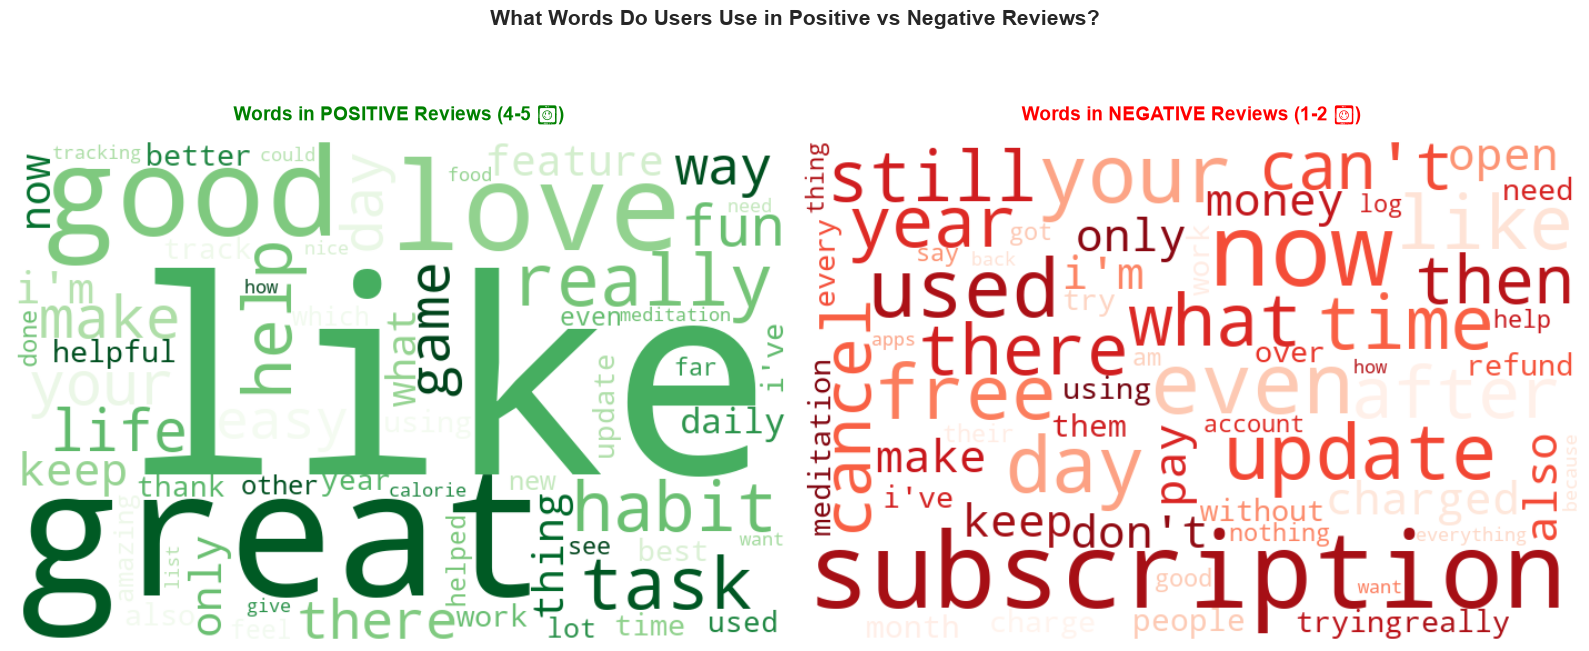

✓ Chart 4 saved!


In [10]:
# Cell 5: Chart 4 - Word Clouds
# Question: "What words appear most in positive vs negative reviews?"

from wordcloud import WordCloud

# Separate positive and negative reviews
positive_text = ' '.join(
    df[df['rating'] >= 4]['review_text_clean'].dropna()
)
negative_text = ' '.join(
    df[df['rating'] <= 2]['review_text_clean'].dropna()
)

# Words to ignore (they appear everywhere, tell us nothing)
stopwords = {
    'app', 'the', 'this', 'it', 'is', 'and', 'to', 'a', 'i',
    'have', 'for', 'of', 'in', 'my', 'its', 'that', 'me',
    'with', 'on', 'but', 'not', 'so', 'just', 'very', 'be',
    'use', 'would', 'much', 'been', 'has', 'are', 'was',
    'they', 'you', 'can', 'an', 'as', 'at', 'do', 'if',
    'get', 'all', 'one', 'when', 'out', 'up', 'more', 'no',
    'will', 'had', 'he', 'she', 'we', 'or', 'from', 'by'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Positive word cloud
wc_pos = WordCloud(
    width=700,
    height=450,
    background_color='white',
    colormap='Greens',
    stopwords=stopwords,
    max_words=60
).generate(positive_text)

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Words in POSITIVE Reviews (4-5 ★)', 
                   fontsize=14, fontweight='bold', 
                   color='green', pad=15)

# Negative word cloud
wc_neg = WordCloud(
    width=700,
    height=450,
    background_color='white',
    colormap='Reds',
    stopwords=stopwords,
    max_words=60
).generate(negative_text)

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Words in NEGATIVE Reviews (1-2 ★)', 
                   fontsize=14, fontweight='bold', 
                   color='red', pad=15)

plt.suptitle('What Words Do Users Use in Positive vs Negative Reviews?',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('outputs/charts/04_wordclouds.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart 4 saved!")

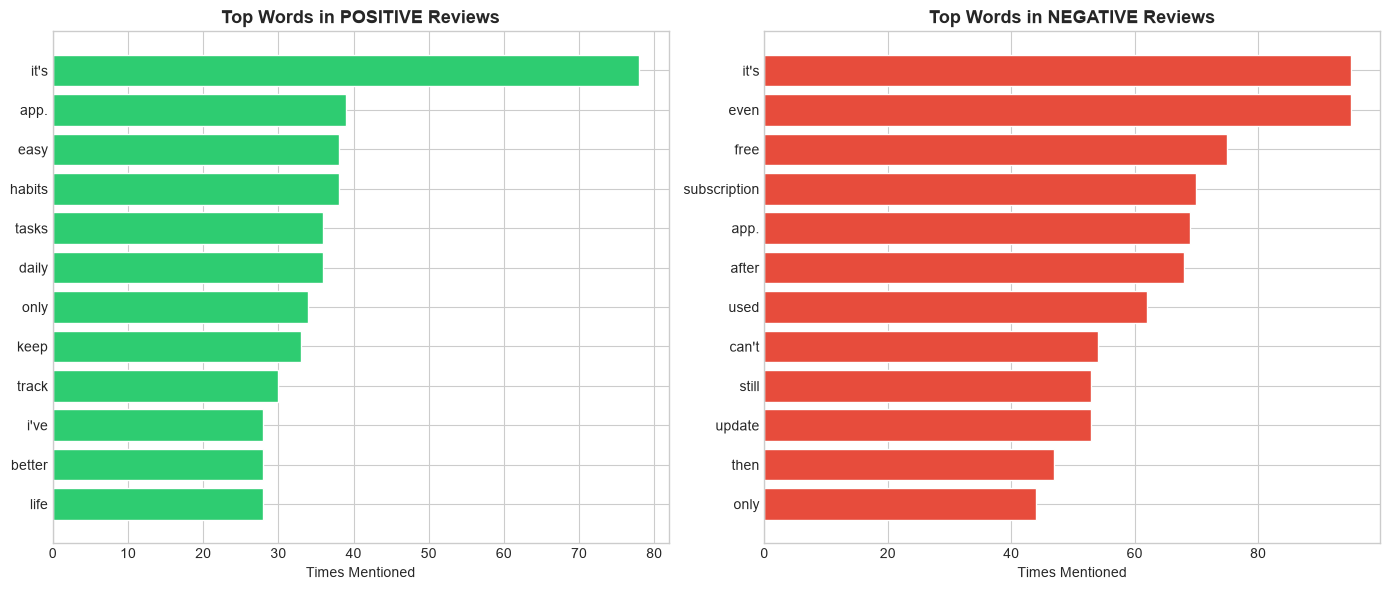

✓ Chart 5 saved!

--- TOP POSITIVE WORDS ---
  it's                 78
  app.                 39
  easy                 38
  habits               38
  tasks                36
  daily                36
  only                 34
  keep                 33
  track                30
  i've                 28
  better               28
  life                 28

--- TOP NEGATIVE WORDS ---
  it's                 95
  even                 95
  free                 75
  subscription         70
  app.                 69
  after                68
  used                 62
  can't                54
  still                53
  update               53
  then                 47
  only                 44


In [11]:
# Cell 6: Chart 5 - Top words as bar charts
# Easier to read exact counts than word clouds

from collections import Counter

def get_top_words(text_series, n=12, exclude=None):
    """Count most common meaningful words"""
    if exclude is None:
        exclude = set()
    
    all_words = []
    for text in text_series.dropna():
        words = str(text).split()
        # Only keep words longer than 3 letters
        # and not in our exclude list
        words = [w for w in words 
                 if len(w) > 3 and w not in exclude]
        all_words.extend(words)
    
    return Counter(all_words).most_common(n)


exclude_words = {
    'app', 'this', 'that', 'have', 'with', 'just',
    'very', 'would', 'been', 'they', 'when', 'from',
    'will', 'more', 'some', 'your', 'which', 'there',
    'their', 'what', 'about', 'really', 'dont', 'cant',
    'good', 'great', 'love', 'like', 'make', 'also'
}

pos_words = get_top_words(
    df[df['rating'] >= 4]['review_text_clean'],
    n=12, exclude=exclude_words
)
neg_words = get_top_words(
    df[df['rating'] <= 2]['review_text_clean'],
    n=12, exclude=exclude_words
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Positive words
pos_df = pd.DataFrame(pos_words, columns=['word', 'count'])
axes[0].barh(
    pos_df['word'][::-1],
    pos_df['count'][::-1],
    color='#2ecc71',
    edgecolor='white'
)
axes[0].set_title('Top Words in POSITIVE Reviews', 
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Times Mentioned')

# Negative words
neg_df = pd.DataFrame(neg_words, columns=['word', 'count'])
axes[1].barh(
    neg_df['word'][::-1],
    neg_df['count'][::-1],
    color='#e74c3c',
    edgecolor='white'
)
axes[1].set_title('Top Words in NEGATIVE Reviews', 
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Times Mentioned')

plt.tight_layout()
plt.savefig('outputs/charts/05_top_keywords.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("✓ Chart 5 saved!")
print("\n--- TOP POSITIVE WORDS ---")
for word, count in pos_words:
    print(f"  {word:20} {count}")

print("\n--- TOP NEGATIVE WORDS ---")
for word, count in neg_words:
    print(f"  {word:20} {count}")

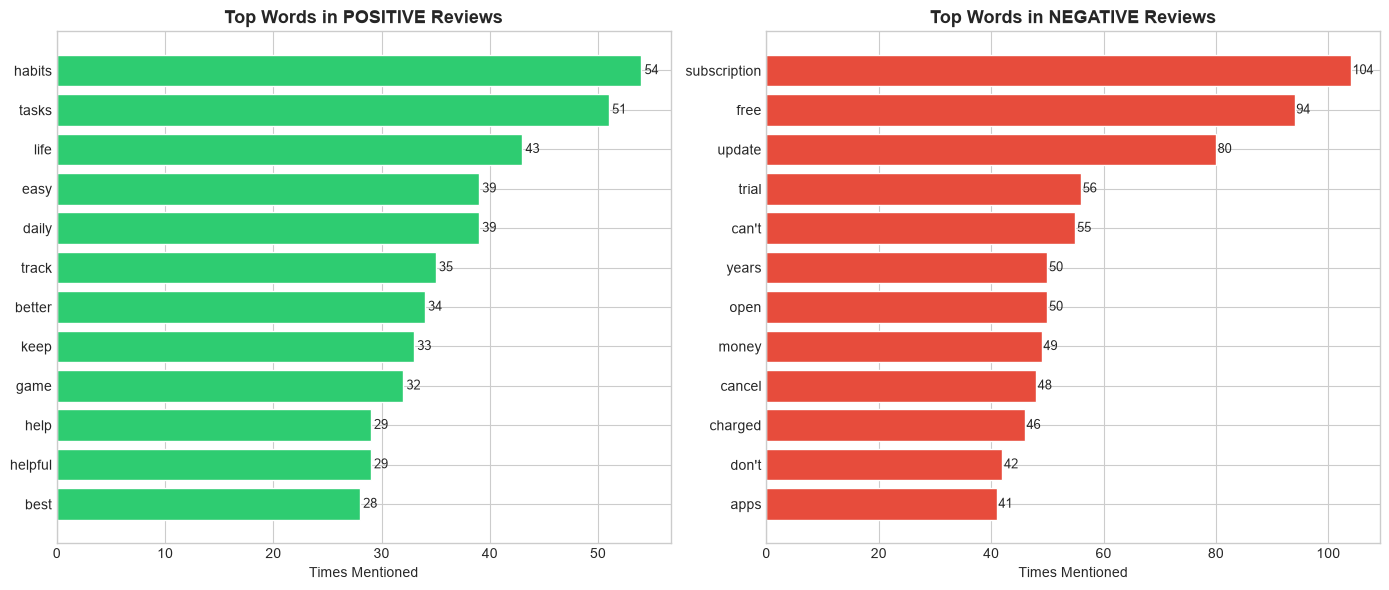

✓ Chart saved!

--- CLEANER POSITIVE WORDS ---
  habits               54
  tasks                51
  life                 43
  easy                 39
  daily                39
  track                35
  better               34
  keep                 33
  game                 32
  help                 29
  helpful              29
  best                 28

--- CLEANER NEGATIVE WORDS ---
  subscription         104
  free                 94
  update               80
  trial                56
  can't                55
  years                50
  open                 50
  money                49
  cancel               48
  charged              46
  don't                42
  apps                 41


In [13]:
# Cell 7: Improved keyword chart with better stopwords

from collections import Counter

exclude_words_v2 = {
    'app', 'this', 'that', 'have', 'with', 'just',
    'very', 'would', 'been', 'they', 'when', 'from',
    'will', 'more', 'some', 'your', 'which', 'there',
    'their', 'what', 'about', 'really', 'dont', 'cant',
    'good', 'great', 'love', 'like', 'make', 'also',
    "it's", "app.", "i've", "i'm", "it.", "i'd",
    'only', 'even', 'after', 'then', 'used', 'still',
    'also', 'into', 'them', 'were', 'than', 'been',
    'over', 'each', 'much', 'well', 'ever', 'once',
    'says', 'said', 'back', 'away', 'came', 'come',
    'gets', 'give', 'gave', 'gone', 'goes', 'want',
    'take', 'took', 'made', 'make', 'know', 'time',
    'every', 'using', 'without', 'before', 'already',
    'because', 'other', 'these', 'those', 'never',
    'always', 'anything', 'something', 'nothing',
    'everything', 'anyone', 'someone', 'never', 'work'
}

def get_top_words_v2(text_series, n=12, exclude=None):
    if exclude is None:
        exclude = set()
    all_words = []
    for text in text_series.dropna():
        words = str(text).split()
        words = [w.strip('.,!?"\'-()[]') for w in words if len(w) > 3 and w not in exclude]
        words = [w for w in words if len(w) > 3 and w not in exclude]
        all_words.extend(words)
    return Counter(all_words).most_common(n)


pos_words_v2 = get_top_words_v2(
    df[df['rating'] >= 4]['review_text_clean'],
    n=12,
    exclude=exclude_words_v2
)

neg_words_v2 = get_top_words_v2(
    df[df['rating'] <= 2]['review_text_clean'],
    n=12,
    exclude=exclude_words_v2
)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Positive words chart
pos_df2 = pd.DataFrame(pos_words_v2, columns=['word', 'count'])
axes[0].barh(pos_df2['word'][::-1], pos_df2['count'][::-1], color='#2ecc71', edgecolor='white')
axes[0].set_title('Top Words in POSITIVE Reviews', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Times Mentioned')

for i, (word, count) in enumerate(zip(pos_df2['word'][::-1], pos_df2['count'][::-1])):
    axes[0].text(count + 0.3, i, str(count), va='center', fontsize=9)

# Negative words chart
neg_df2 = pd.DataFrame(neg_words_v2, columns=['word', 'count'])
axes[1].barh(neg_df2['word'][::-1], neg_df2['count'][::-1], color='#e74c3c', edgecolor='white')
axes[1].set_title('Top Words in NEGATIVE Reviews', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Times Mentioned')

for i, (word, count) in enumerate(zip(neg_df2['word'][::-1], neg_df2['count'][::-1])):
    axes[1].text(count + 0.3, i, str(count), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/charts/05b_top_keywords_clean.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Chart saved!")
print("\n--- CLEANER POSITIVE WORDS ---")
for word, count in pos_words_v2:
    print(f"  {word:20} {count}")

print("\n--- CLEANER NEGATIVE WORDS ---")
for word, count in neg_words_v2:
    print(f"  {word:20} {count}")